<a href="https://colab.research.google.com/github/PrashantAghara/retail-mesh/blob/master/notebooks/Yolo_Retail_Mesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
sys.path.append("..")

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected — training will run on CPU (slow) or consider Google Colab for the training step")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 5.5 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.predict(source="https://ultralytics.com/images/bus.jpg", save=False)

result = results[0]
print(f"Detected {len(result.boxes)} objects")
for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    print(f"  {class_name}: {confidence:.2f} confidence")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 8.4ms
Speed: 94.1ms preprocess, 8.4ms inference, 44.7ms postprocess per image at shape (1, 3, 640, 480)
Detected 5 objects
  bus: 0.94 confidence
  person: 0.89 confidence
  person: 0.88 confidence
  person: 0.86 confidence
  person: 0.62 confidence


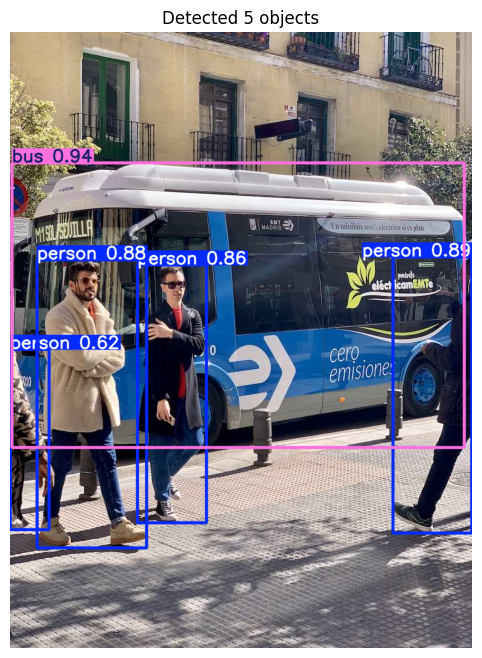

In [4]:
import matplotlib.pyplot as plt

annotated = result.plot()

plt.figure(figsize=(10, 8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.title(f"Detected {len(result.boxes)} objects")
plt.show()

In [5]:
box = result.boxes[0]
print(f"Class: {model.names[int(box.cls[0])]}")
print(f"Confidence: {float(box.conf[0]):.3f}")
print(f"Bounding box (x1, y1, x2, y2): {box.xyxy[0].tolist()}")

Class: bus
Confidence: 0.940
Bounding box (x1, y1, x2, y2): [3.8327693939208984, 229.36419677734375, 796.194580078125, 728.4122314453125]


### Yolo Training

In [6]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="SKU-110K.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    patience=5,
    project="retailmesh",
    name="shelf_detection",
)

Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SKU-110K.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shelf_detection, nbs=64, nms=False, opset=None, 

In [8]:
!ls /content/runs/detect/retailmesh/shelf_detection/weights

best.pt  last.pt


In [9]:
trained_model = YOLO("/content/runs/detect/retailmesh/shelf_detection/weights/best.pt")

val_results = trained_model.val(data="SKU-110K.yaml")
print(f"mAP50: {val_results.box.map50:.3f}")
print(f"mAP50-95: {val_results.box.map:.3f}")

Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2798.1±511.8 MB/s, size: 1324.8 KB)
val: Scanning /content/datasets/SKU-110K/labels.cache... 588 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 588/588 112.1Mit/s 0.0s
val: /content/datasets/SKU-110K/images/val_0.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_115.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_127.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_166.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_172.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_190.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_2.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU

In [10]:
from google.colab import files
files.download("/content/runs/detect/retailmesh/shelf_detection/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>